In [3]:
import utils_FaIR_JAX
import matplotlib.pyplot as plt
import glob
import numpy as np
import jax.numpy as jnp
import utils_plotting
import pickle
from paths import DATA_DIR

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Phase 1: Calibrate climate sensitivity via prescribed CO2 concentrations -> $\Delta T$

In [ ]:
conc_path = str(DATA_DIR / 'MESM' / 'conc_driven')
conc_1pct_path = f'{conc_path}/1PRCO2/'


In [5]:
def calculate_ensemble_average(file_pattern):
    # Find all files matching the string pattern (e.g., 'dt2m_ascii_*.txt')
    file_list = glob.glob(file_pattern)

    if not file_list:
        print("No files found matching the pattern.")
        return None

    all_data = []

    for file in file_list:
        # Load the data; np.loadtxt handles the whitespace formatting automatically
        # usecols=(1,) extracts the values from the 2nd column in the text file
        # (which corresponds to your data values like -0.036, 0.064, etc.)
        data = np.loadtxt(file, usecols=(1,))
        all_data.append(data)

    # Stack the list into a 2D array: (number_of_members, number_of_timesteps)
    ensemble_stack = np.stack(all_data)

    # Take the mean across the ensemble members (axis 0)
    ensemble_average = np.mean(ensemble_stack, axis=0)

    return ensemble_average

In [6]:
avg_1pct = calculate_ensemble_average(conc_1pct_path + 'dt2m_ascii_*.txt')
target_dict = {'1pctCO2': avg_1pct}

In [7]:
n_years_1pct = len(avg_1pct)

base_co2 = 286.4
co2_1pct = base_co2 * (1.01 **  np.arange(n_years_1pct))
conc_mat_1pct = jnp.zeros((3, len(co2_1pct)))
conc_mat_1pct = conc_mat_1pct.at[0,:].set(co2_1pct)
conc_mat_1pct = conc_mat_1pct.at[1,:].set(720.0)
conc_mat_1pct = conc_mat_1pct.at[2,:].set(270.0)

conc_dict = {'1pctCO2': conc_mat_1pct}
emis_dict = {'1pctCO2': jnp.zeros((5, len(co2_1pct)))}

In [ ]:
filepath = 'data/JAX_calibration/calib_MESM_CO2_only.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')

# Compute migrated to scripts/2c_calibrate_MESM.py (run standalone / scheduled) - this cell just loads the calibrated theta.
with open(filepath, 'rb') as f:
    theta_opt = pickle.load(f)
utils_plotting.plot_calibration_results(conc_dict, emis_dict, target_dict, theta0, theta_opt, dt=0.1)


### Phase 2: Calibrate carbon cycle via emissions -> concentrations

In [ ]:
emis_path = str(DATA_DIR / 'MESM' / 'emis_driven')
emis_1pct_path = f'{emis_path}/1PRCO2/carbemiss.txt'

emis_1pct = np.loadtxt(emis_1pct_path, usecols=(2,), skiprows=2)
emis_mat_1pct = jnp.zeros((5, len(emis_1pct)))
emis_mat_1pct = emis_mat_1pct.at[0,:].set(emis_1pct)
emis_dict = {'1pctCO2': emis_mat_1pct}
target_conc_dict = {'1pctCO2': conc_mat_1pct}


In [ ]:
filepath = 'data/JAX_calibration/calib_MESM_emis_to_conc.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')

# Compute migrated to scripts/2c_calibrate_MESM.py (run standalone / scheduled) - this cell just loads the calibrated theta.
with open(filepath, 'rb') as f:
    theta_opt_emis = pickle.load(f)
utils_plotting.plot_calibration_results(None, emis_dict, target_conc_dict, theta0, theta_opt_emis, dt=0.1, calib='Carbon')


### Phase 3: emissions to temperature (verification)

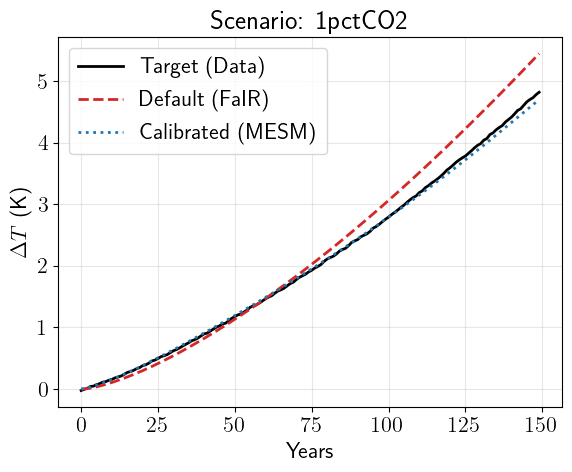

In [29]:
utils_plotting.plot_model_comparison(emis_dict, {'1pctCO2': target_dict['1pctCO2']}, theta0, mode='MESM', dt=0.1)